Loading data...
Loaded 20631 records from 100 engines
Total records: 20631
Total engines: 100
Feature columns: 24 (3 settings + 21 sensors)
Calculating RUL...
Creating health labels...

Health Status Distribution:
  Failure (0): 5,100 (24.7%)
  Warning (1): 7,500 (36.4%)
  Healthy (2): 8,031 (38.9%)

Preparing features...
Training set: 16,504 samples
Test set: 4,127 samples

TRAINING MODELS

Training Logistic Regression...
  ✓ Accuracy: 0.7066

Training Random Forest...
  ✓ Accuracy: 0.7272

Training K-Nearest Neighbors...
  ✓ Accuracy: 0.6789

MODEL EVALUATION

               Model Accuracy Failure Recall Failure F1 Warning F1 Healthy F1
Logistic Regression   0.7066         0.8471     0.8336     0.5922     0.7297
      Random Forest   0.7272         0.8304     0.8543     0.6127     0.7499
K-Nearest Neighbors   0.6789         0.7980     0.8210     0.5622     0.6980

 Best Model (by Failure Recall): Logistic Regression (Failure Recall: 0.8471)

Full Classification Report (Best Model):
 

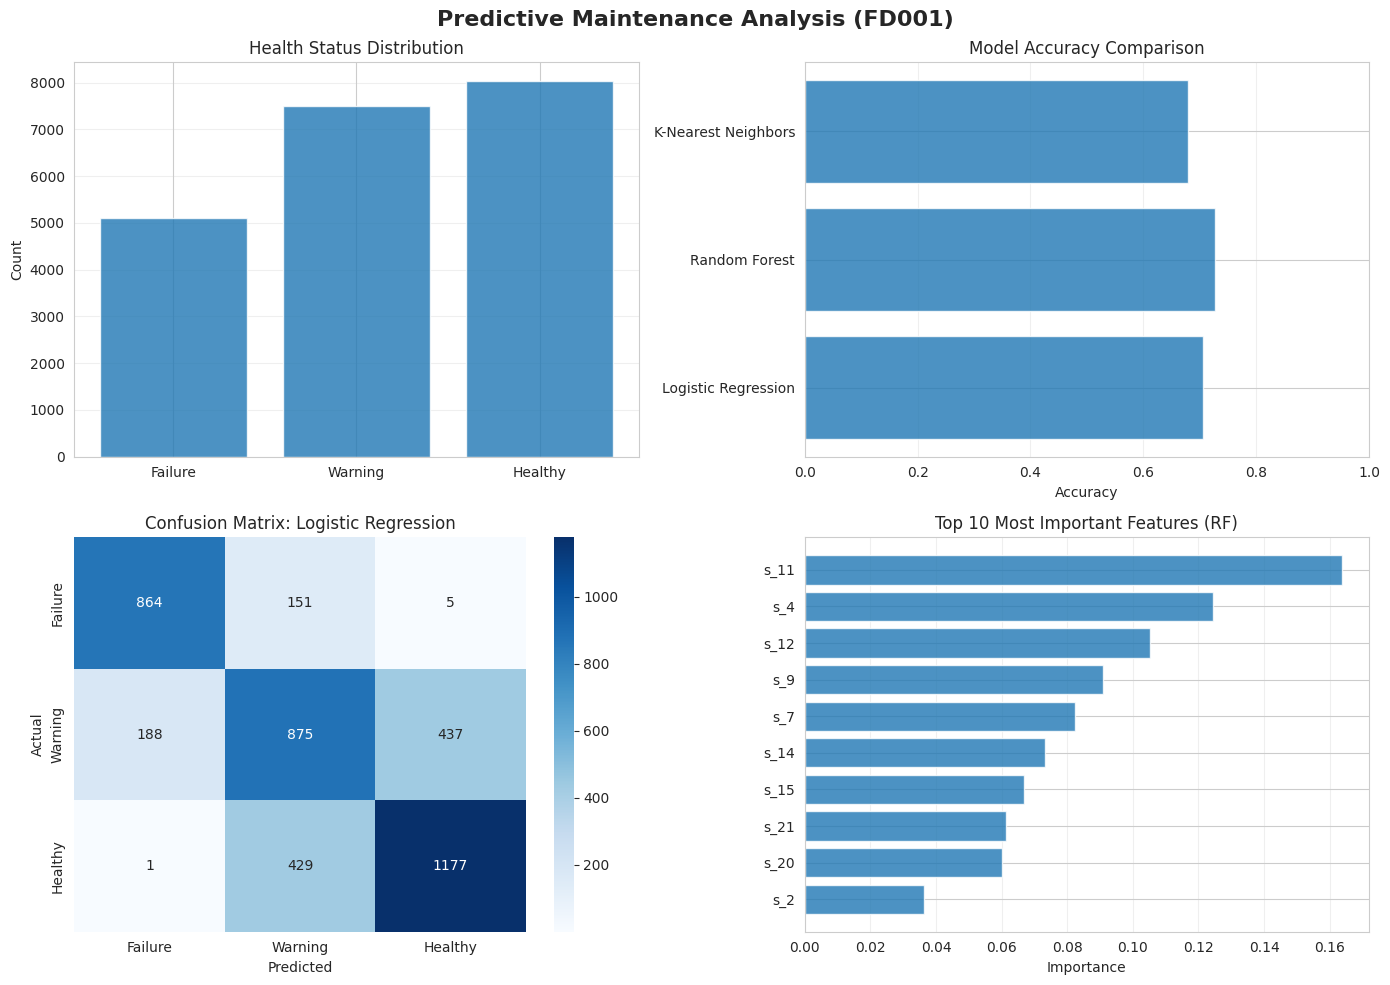

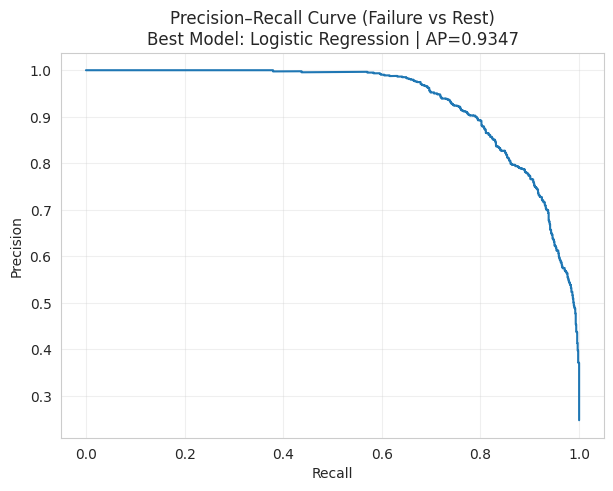


✓ Analysis complete!


In [1]:
#final
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_curve,
    average_precision_score
)

import warnings
warnings.filterwarnings('ignore')
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100


# =========================
# CONFIG (IMPORTANT)
# =========================
# Keep baseline outputs identical to your report:
BASELINE_MODE = True   # True => keep your current fixed params and selection logic (same reported numbers)
RUN_PR_CURVE   = True  # Only adds a plot; does NOT change model or metrics
RUN_TUNING     = False # Keep False to avoid changing reported numbers


def resolve_fd001_path() -> str:
    """
    Find FD001 training file path automatically (Kaggle folder variants).
    Keeps your report path as the first option.
    """
    candidates = [
        "/kaggle/input/nasa-cmaps/CMaps/train_FD001.txt",
        "/kaggle/input/nasa-cmaps/cmaps/CMaps/train_FD001.txt",
        "/kaggle/input/nasa-cmaps/CMaps/train_FD001.TXT",
        "/kaggle/input/nasa-cmaps/cmaps/CMaps/train_FD001.TXT",
    ]
    for p in candidates:
        if os.path.exists(p):
            return p
    # Fallback: show helpful error
    raise FileNotFoundError(
        "Could not find train_FD001.txt in expected Kaggle paths. "
        "Please set the correct filepath manually."
    )


class EngineHealthPredictor:
    """
    Predictive maintenance system for aircraft engines (CMAPSS FD001)

    Label mapping (IMPORTANT - keep consistent everywhere):
      0 = Failure (RUL <= 50)
      1 = Warning (50 < RUL <= 125)
      2 = Healthy (RUL > 125)
    """

    # Health thresholds (cycles)
    FAILURE_THRESHOLD = 50
    WARNING_THRESHOLD = 125

    def __init__(self, filepath):
        self.filepath = filepath
        self.df = None

        self.X_train = None
        self.X_test = None
        self.y_train = None
        self.y_test = None

        self.scaler = StandardScaler()
        self.models = {}
        self.results = {}

        # Track best model name (by Failure Recall)
        self.best_model_name = None

        # Column names for features
        self.setting_cols = ['setting_1', 'setting_2', 'setting_3']
        self.sensor_cols = [f's_{i}' for i in range(1, 22)]
        self.feature_cols = self.setting_cols + self.sensor_cols  # settings + sensors

        # Human-readable labels for plots
        self.label_names = {0: "Failure", 1: "Warning", 2: "Healthy"}

    def load_data(self):
        """Load and prepare raw C-MAPSS data"""
        print("Loading data...")

        col_names = ['unit_nr', 'time_cycles'] + self.setting_cols + self.sensor_cols

        df = pd.read_csv(self.filepath, sep=r'\s+', header=None)

        # Some CMAPSS txt files may contain an extra empty last column -> drop if needed
        if df.shape[1] > len(col_names):
            df = df.iloc[:, :len(col_names)]

        df.columns = col_names
        self.df = df

        # Dataset stats (for report) - does not change any modeling outputs
        print(f"Loaded {len(self.df)} records from {self.df['unit_nr'].nunique()} engines")
        print(f"Total records: {len(self.df)}")
        print(f"Total engines: {self.df['unit_nr'].nunique()}")
        print(f"Feature columns: {len(self.feature_cols)} (3 settings + 21 sensors)")
        return self

    def calculate_rul(self):
        """Calculate Remaining Useful Life for each record"""
        print("Calculating RUL...")

        max_cycles = self.df.groupby('unit_nr')['time_cycles'].max().reset_index()
        max_cycles.columns = ['unit_nr', 'max_cycle']

        self.df = self.df.merge(max_cycles, on='unit_nr', how='left')
        self.df['RUL'] = self.df['max_cycle'] - self.df['time_cycles']
        self.df.drop(columns=['max_cycle'], inplace=True)

        return self
 
    def create_labels(self):
        """Create health status labels based on RUL"""
        print("Creating health labels...")

        def classify_health(rul):
            if rul <= self.FAILURE_THRESHOLD:
                return 0  # Failure
            elif rul <= self.WARNING_THRESHOLD:
                return 1  # Warning
            else:
                return 2  # Healthy

        self.df['label'] = self.df['RUL'].apply(classify_health).astype(int)

        label_counts = self.df['label'].value_counts().sort_index()
        print("\nHealth Status Distribution:")
        for k in [0, 1, 2]:
            cnt = int(label_counts.get(k, 0))
            print(f"  {self.label_names[k]} ({k}): {cnt:,} ({cnt/len(self.df)*100:.1f}%)")

        return self

    def prepare_features(self, test_size=0.2, random_state=42):
        """Select features and split data"""
        print("\nPreparing features...")

        X = self.df[self.feature_cols].copy()
        y = self.df['label'].copy()

        # Keep split identical to your report (random_state fixed, stratify enabled)
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )

        # Scale features (required for LogReg/KNN)
        self.X_train = self.scaler.fit_transform(self.X_train)
        self.X_test = self.scaler.transform(self.X_test)

        print(f"Training set: {len(self.X_train):,} samples")
        print(f"Test set: {len(self.X_test):,} samples")

        return self

    def train_models(self):
        """Train multiple classification models (baseline params preserved)"""
        print("\n" + "=" * 60)
        print("TRAINING MODELS")
        print("=" * 60)

        # Baseline params (keep same as your report)
        self.models = {
            "Logistic Regression": LogisticRegression(
                max_iter=2000,
                class_weight='balanced',
                random_state=42
            ),
            "Random Forest": RandomForestClassifier(
                n_estimators=200,
                max_depth=10,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            ),
            "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5)
        }

        for name, model in self.models.items():
            print(f"\nTraining {name}...")
            model.fit(self.X_train, self.y_train)

            y_pred = model.predict(self.X_test)

            acc = accuracy_score(self.y_test, y_pred)
            report_dict = classification_report(
                self.y_test, y_pred,
                output_dict=True,
                zero_division=0
            )

            self.results[name] = {
                "accuracy": acc,
                "report": report_dict,
                "predictions": y_pred,
                "model": model
            }

            print(f"  ✓ Accuracy: {acc:.4f}")

        return self

    def evaluate(self):
        """Compare performance; select best model by Failure Recall (class 0)"""
        print("\n" + "=" * 60)
        print("MODEL EVALUATION")
        print("=" * 60)

        comparison = []
        for name, data in self.results.items():
            report = data['report']
            comparison.append({
                "Model": name,
                "Accuracy": f"{data['accuracy']:.4f}",
                "Failure Recall": f"{report['0']['recall']:.4f}",
                "Failure F1": f"{report['0']['f1-score']:.4f}",
                "Warning F1": f"{report['1']['f1-score']:.4f}",
                "Healthy F1": f"{report['2']['f1-score']:.4f}",
            })

        comparison_df = pd.DataFrame(comparison)
        print("\n", comparison_df.to_string(index=False))

        # Select best by Failure Recall (keeps your report logic)
        best = max(self.results.items(), key=lambda x: x[1]['report']['0']['recall'])
        self.best_model_name = best[0]

        best_recall = best[1]['report']['0']['recall']
        print(f"\n Best Model (by Failure Recall): {self.best_model_name} (Failure Recall: {best_recall:.4f})")

        # Full report (fixed labels order)
        y_pred_best = self.results[self.best_model_name]['predictions']
        print("\nFull Classification Report (Best Model):")
        print(classification_report(
            self.y_test, y_pred_best,
            labels=[0, 1, 2],
            target_names=["Failure", "Warning", "Healthy"],
            digits=4,
            zero_division=0
        ))

        return self

    def plot_pr_curve_failure(self):
        """
        Precision-Recall curve for Failure class (0) vs Rest.
        This DOES NOT change training/evaluation outputs.
        """
        if self.best_model_name is None:
            raise RuntimeError("Run evaluate() before plot_pr_curve_failure().")

        model = self.results[self.best_model_name]['model']

        if not hasattr(model, "predict_proba"):
            print(f"PR curve skipped: {self.best_model_name} does not support predict_proba.")
            return self

        # One-vs-rest for Failure class
        y_true = (self.y_test.values == 0).astype(int)  # 1 if Failure else 0
        proba = model.predict_proba(self.X_test)

        # Probability of class 0
        # Ensure class order matches [0,1,2]
        class_order = list(getattr(model, "classes_", [0, 1, 2]))
        idx0 = class_order.index(0)
        y_score = proba[:, idx0]

        precision, recall, _ = precision_recall_curve(y_true, y_score)
        ap = average_precision_score(y_true, y_score)

        plt.figure(figsize=(7, 5))
        plt.plot(recall, precision)
        plt.title(f"Precision–Recall Curve (Failure vs Rest)\nBest Model: {self.best_model_name} | AP={ap:.4f}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.grid(alpha=0.3)
        plt.show()

        return self

    def visualize_results(self):
        """Create visualization plots (CM for best model)"""
        if self.best_model_name is None:
            raise RuntimeError("Run evaluate() before visualize_results() so best model is selected.")

        print("\nGenerating visualizations...")

        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        fig.suptitle('Predictive Maintenance Analysis (FD001)', fontsize=16, fontweight='bold')

        # 1) Class Distribution
        ax1 = axes[0, 0]
        label_counts = self.df['label'].value_counts().sort_index()
        ax1.bar(["Failure", "Warning", "Healthy"],
                [label_counts.get(0, 0), label_counts.get(1, 0), label_counts.get(2, 0)],
                alpha=0.8)
        ax1.set_ylabel('Count')
        ax1.set_title('Health Status Distribution')
        ax1.grid(axis='y', alpha=0.3)

        # 2) Model Accuracy Comparison
        ax2 = axes[0, 1]
        model_names = list(self.results.keys())
        accuracies = [self.results[m]['accuracy'] for m in model_names]
        ax2.barh(model_names, accuracies, alpha=0.8)
        ax2.set_xlabel('Accuracy')
        ax2.set_title('Model Accuracy Comparison')
        ax2.set_xlim([0, 1])
        ax2.grid(axis='x', alpha=0.3)

        # 3) Confusion Matrix (BEST MODEL)
        ax3 = axes[1, 0]
        best_pred = self.results[self.best_model_name]['predictions']
        cm = confusion_matrix(self.y_test, best_pred, labels=[0, 1, 2])

        sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", ax=ax3,
                    xticklabels=["Failure", "Warning", "Healthy"],
                    yticklabels=["Failure", "Warning", "Healthy"])
        ax3.set_title(f'Confusion Matrix: {self.best_model_name}')
        ax3.set_xlabel('Predicted')
        ax3.set_ylabel('Actual')

        # 4) Feature Importance (Random Forest)
        ax4 = axes[1, 1]
        rf_name = "Random Forest"
        if rf_name in self.results:
            rf_model = self.results[rf_name]['model']
            if hasattr(rf_model, "feature_importances_"):
                importances = rf_model.feature_importances_
                indices = np.argsort(importances)[::-1][:10]  # Top 10
                feature_names = self.feature_cols

                ax4.barh([feature_names[i] for i in indices], importances[indices], alpha=0.8)
                ax4.set_xlabel('Importance')
                ax4.set_title('Top 10 Most Important Features (RF)')
                ax4.invert_yaxis()
                ax4.grid(axis='x', alpha=0.3)
            else:
                ax4.text(0.1, 0.5, "RF feature importance not available", fontsize=12)
                ax4.set_axis_off()
        else:
            ax4.text(0.1, 0.5, "Random Forest not available", fontsize=12)
            ax4.set_axis_off()

        plt.tight_layout()
        plt.show()

        return self


def main():
    # Keep your report path style, but resolve automatically for portability
    filepath = resolve_fd001_path()

    predictor = EngineHealthPredictor(filepath)
    predictor.load_data() \
             .calculate_rul() \
             .create_labels() \
             .prepare_features() \
             .train_models() \
             .evaluate() \
             .visualize_results()

    if RUN_PR_CURVE:
        predictor.plot_pr_curve_failure()

    print("\n✓ Analysis complete!")


if __name__ == "__main__":
    main()
